# 04  Reinforcement Learning Environment
---

## What this notebook does

This notebook implements the **RL scheduling environment**  the core of the thesis.

It formalises the task scheduling problem as a **Markov Decision Process (MDP)**
and builds a gym-style environment the DQN agent will train inside.

### MDP Formulation

| Component | Definition |
|---|---|
| **State S** | 7-feature vector per task × up to 20 tasks = 140-dim observation |
| **Action A** | Select which task to execute next (discrete, 0 to n_tasks-1) |
| **Reward R** | +10 on-time, −15 missed deadline, −2 reorder, +5 dependency resolved |
| **Discount γ** | 0.95 (near-term deadlines weighted more heavily) |
| **Episode** | One complete 600-minute working day scenario |

### State features per task (7 total)
| Feature | Description | Range |
|---|---|---|
| `deadline_urgency` | How close is the deadline relative to remaining workday | 0–1 |
| `duration_norm` | Task duration normalised to 0–1 | 0–1 |
| `priority_norm` | Priority 1–5 normalised to 0–1 | 0–1 |
| `has_dependency` | Binary — does this task have unmet dependencies | 0 or 1 |
| `is_vague` | Binary — was this task extracted with low NLP confidence | 0 or 1 |
| `time_pressure` | Duration / time remaining until deadline | 0–1 |
| `is_available` | Binary — real task slot vs padding | 0 or 1 |

### Notebook structure
1. Imports and configuration
2. MDP formulation recap
3. State encoding
4. Reward function
5. Environment class (TaskSchedulerEnv)
6. Environment validation
7. Episode walkthrough
8. Disruption handling test
9. Environment statistics
10. Compatibility check for DQN training


## 1. Imports and Configuration

In [1]:
import json
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

random.seed(42)
np.random.seed(42)

# ── Paths ─────────────────────────────────────────────────────────────────────
TRAIN_PATH = "data/train_scenarios.json"
TEST_PATH  = "data/test_scenarios.json"

# ── Configuration ─────────────────────────────────────────────────────────────
WORKDAY_MINUTES = 600
MAX_TASKS       = 20
N_FEATURES      = 7
STATE_SIZE      = MAX_TASKS * N_FEATURES   # 140

GAMMA           = 0.95

# ── Reward values ─────────────────────────────────────────────────────────────
R_ON_TIME      = +10.0
R_MISSED       = -15.0
R_REORDER      = -2.0
R_DEP_RESOLVED = +5.0
R_VAGUE        = +3.0

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.size":        11,
})
PALETTE = ["#1D9E75", "#534AB7", "#BA7517", "#2E75B6", "#D85A30"]

print("Configuration loaded.")
print(f"State size       : {STATE_SIZE} ({MAX_TASKS} tasks x {N_FEATURES} features)")
print(f"Discount factor  : {GAMMA}")
print(f"Reward on-time   : {R_ON_TIME}")
print(f"Reward missed    : {R_MISSED}")
print(f"Reward reorder   : {R_REORDER}")
print(f"Reward dep.      : {R_DEP_RESOLVED}")


Configuration loaded.
State size       : 140 (20 tasks x 7 features)
Discount factor  : 0.95
Reward on-time   : 10.0
Reward missed    : -15.0
Reward reorder   : -2.0
Reward dep.      : 5.0


## 2. MDP Formulation Recap

In [2]:
print("=" * 60)
print("  FORMAL MDP DEFINITION")
print("  Autonomous Task Scheduling Problem")
print("=" * 60)
print()
print(f"  STATE SPACE S  : {STATE_SIZE}-dimensional vector")
print(f"                   {MAX_TASKS} task slots x {N_FEATURES} features each")
print()
print("  ACTION SPACE A : Discrete {0, 1, ..., 19}")
print("                   Action i = execute task at queue position i")
print()
print("  REWARD R(s,a)  :")
print(f"    On-time completion    : {R_ON_TIME:+.1f}")
print(f"    Missed deadline       : {R_MISSED:+.1f}")
print(f"    Unnecessary reorder   : {R_REORDER:+.1f}")
print(f"    Dependency resolved   : {R_DEP_RESOLVED:+.1f}")
print(f"    Vague task completed  : {R_VAGUE:+.1f}")
print()
print(f"  DISCOUNT FACTOR: gamma = {GAMMA}")
print()
print("  EPISODE        : One 600-minute working day")
print("                   Ends when queue empty OR time >= 600")
print("=" * 60)


  FORMAL MDP DEFINITION
  Autonomous Task Scheduling Problem

  STATE SPACE S  : 140-dimensional vector
                   20 task slots x 7 features each

  ACTION SPACE A : Discrete {0, 1, ..., 19}
                   Action i = execute task at queue position i

  REWARD R(s,a)  :
    On-time completion    : +10.0
    Missed deadline       : -15.0
    Unnecessary reorder   : -2.0
    Dependency resolved   : +5.0
    Vague task completed  : +3.0

  DISCOUNT FACTOR: gamma = 0.95

  EPISODE        : One 600-minute working day
                   Ends when queue empty OR time >= 600


## 3. State Encoding

The state encoder converts the task queue into a fixed-size numerical
vector. Each task is encoded as a 7-feature vector. Empty task slots
are zero-padded to always produce a fixed 140-dimensional state.


In [3]:
def encode_task(task, current_time, completed_ids):
    """
    Encode a single task into a 7-dimensional feature vector.
    All values normalised to [0, 1] for stable NN training.

    Parameters:
        task          : task dict
        current_time  : current simulation time (minutes)
        completed_ids : set of completed task IDs (for dependency check)

    Returns:
        np.array of shape (7,)
    """
    # Feature 1: deadline urgency
    time_left        = max(task['deadline_min'] - current_time, 0)
    deadline_urgency = 1.0 - (time_left / WORKDAY_MINUTES)
    deadline_urgency = float(np.clip(deadline_urgency, 0.0, 1.0))

    # Feature 2: duration normalised
    duration_norm = float(np.clip(task['duration_min'] / 240.0, 0.0, 1.0))

    # Feature 3: priority normalised
    priority_norm = (task['priority'] - 1) / 4.0

    # Feature 4: has unmet dependency
    unmet_deps     = [d for d in task.get('dependencies', [])
                      if d not in completed_ids]
    has_dependency = 1.0 if unmet_deps else 0.0

    # Feature 5: vague flag
    is_vague = 1.0 if task.get('vague', False) else 0.0

    # Feature 6: time pressure
    time_pressure = float(np.clip(
        task['duration_min'] / max(time_left, 1), 0.0, 1.0
    ))

    # Feature 7: slot is a real task (not padding)
    is_available = 1.0

    return np.array([
        deadline_urgency,
        duration_norm,
        priority_norm,
        has_dependency,
        is_vague,
        time_pressure,
        is_available,
    ], dtype=np.float32)


def encode_state(task_queue, current_time, completed_ids):
    """
    Encode the full task queue into a flat state vector of shape (140,).
    Tasks beyond MAX_TASKS are truncated. Empty slots are zero-padded.

    Parameters:
        task_queue    : list of task dicts
        current_time  : current simulation time (minutes)
        completed_ids : set of completed task IDs

    Returns:
        np.array of shape (STATE_SIZE,) = (140,)
    """
    state = np.zeros((MAX_TASKS, N_FEATURES), dtype=np.float32)
    for i, task in enumerate(task_queue[:MAX_TASKS]):
        state[i] = encode_task(task, current_time, completed_ids)
    return state.flatten()


# ── Preview: encode one task ──────────────────────────────────────────────────
with open(TRAIN_PATH) as f:
    train_scenarios = json.load(f)

sample_task = train_scenarios[0]['tasks'][0]
sample_vec  = encode_task(sample_task, current_time=0, completed_ids=set())

feature_names = ['deadline_urgency', 'duration_norm', 'priority_norm',
                 'has_dependency', 'is_vague', 'time_pressure', 'is_available']

print("Sample task encoding:")
print(f"  Task    : {sample_task['name']}")
print(f"  Deadline: {sample_task['deadline_min']} min")
print(f"  Duration: {sample_task['duration_min']} min")
print(f"  Priority: {sample_task['priority']}")
print()
print("  Feature vector:")
for name, val in zip(feature_names, sample_vec):
    bar = '█' * int(val * 20)
    print(f"  {name:<20} {val:.4f}  {bar}")

full_state = encode_state(train_scenarios[0]['tasks'], 0, set())
print()
print(f"  Full state vector shape: {full_state.shape}")


Sample task encoding:
  Task    : Review product pull request
  Deadline: 201 min
  Duration: 150 min
  Priority: 3

  Feature vector:
  deadline_urgency     0.6650  █████████████
  duration_norm        0.6250  ████████████
  priority_norm        0.5000  ██████████
  has_dependency       0.0000  
  is_vague             0.0000  
  time_pressure        0.7463  ██████████████
  is_available         1.0000  ████████████████████

  Full state vector shape: (140,)


## 4. Reward Function

The reward function defines what the agent is optimising for.

**Design rationale:**
- Missed penalty (−15) > on-time reward (+10): asymmetry encourages deadline-aware scheduling
- Dependency bonus (+5): rewards thinking ahead
- Reorder penalty (−2): discourages unnecessary task switching


In [4]:
def compute_reward(task, finish_time, prev_order, completed_ids):
    """
    Compute reward for completing a task.

    Parameters:
        task          : task dict just completed
        finish_time   : simulation time when task finished
        prev_order    : list of task IDs in previous queue order
        completed_ids : set of already-completed task IDs

    Returns:
        reward (float), info (dict)
    """
    reward = 0.0
    info   = {}

    # Primary: on-time vs missed
    if finish_time <= task['deadline_min']:
        if task.get('vague', False):
            reward += R_VAGUE
            info['on_time'] = True
            info['vague_completion'] = True
        else:
            reward += R_ON_TIME
            info['on_time'] = True
    else:
        reward += R_MISSED
        info['on_time'] = False
        info['overdue_by'] = finish_time - task['deadline_min']

    # Bonus: dependency chain resolved
    for dep_id in task.get('dependencies', []):
        if dep_id in completed_ids:
            reward += R_DEP_RESOLVED
            info['dep_bonus'] = info.get('dep_bonus', 0) + 1

    # Penalty: unnecessary reorder
    if prev_order and len(prev_order) > 0 and task['id'] != prev_order[0]:
        reward += R_REORDER
        info['reorder_penalty'] = True

    info['reward'] = reward
    return reward, info


# ── Demonstrate reward cases ──────────────────────────────────────────────────
t = {'id': 'T001', 'name': 'Test task', 'deadline_min': 300,
     'duration_min': 60, 'priority': 4, 'dependencies': [], 'vague': False}

print("Reward function demonstration:")
print()
r, i = compute_reward(t, 280, ['T001'], set())
print(f"  On-time  (finish=280, deadline=300) : {r:+.1f}  info={i}")

r, i = compute_reward(t, 320, ['T001'], set())
print(f"  Missed   (finish=320, deadline=300) : {r:+.1f}  info={i}")

r, i = compute_reward(t, 280, ['T002', 'T001'], set())
print(f"  On-time + reorder penalty           : {r:+.1f}  info={i}")

t_dep = {**t, 'dependencies': ['T000']}
r, i = compute_reward(t_dep, 280, ['T001'], {'T000'})
print(f"  On-time + dep resolved              : {r:+.1f}  info={i}")


Reward function demonstration:

  On-time  (finish=280, deadline=300) : +10.0  info={'on_time': True, 'reward': 10.0}
  Missed   (finish=320, deadline=300) : -15.0  info={'on_time': False, 'overdue_by': 20, 'reward': -15.0}
  On-time + reorder penalty           : +8.0  info={'on_time': True, 'reorder_penalty': True, 'reward': 8.0}
  On-time + dep resolved              : +15.0  info={'on_time': True, 'dep_bonus': 1, 'reward': 15.0}


## 5. TaskSchedulerEnv — The RL Environment

Gym-style environment with:
- `reset()` — start a new episode
- `step(action)` — execute a task, return (state, reward, done, info)
- `get_metrics()` — return TCR, DD, episode reward
- `action_mask()` — valid action indices
- Safety timeout: max 200 steps per episode to prevent infinite loops


In [5]:
class TaskSchedulerEnv:
    """
    Gym-style RL environment for task scheduling.
    One episode = one complete 600-minute working day scenario.
    """

    def __init__(self, scenarios, workday_minutes=WORKDAY_MINUTES, seed=42):
        self.scenarios               = scenarios
        self.workday_minutes         = workday_minutes
        self.rng                     = random.Random(seed)
        self.observation_space_shape = (STATE_SIZE,)
        self.action_space_n          = MAX_TASKS
        # Episode state
        self.task_queue              = []
        self.pending_disrupts        = []
        self.current_time            = 0
        self.completed               = []
        self.missed                  = []
        self.episode_reward          = 0.0
        self.prev_order              = []
        self.scenario                = None
        self.steps                   = 0

    def reset(self):
        """Start a new episode. Returns initial state vector."""
        self.scenario         = self.rng.choice(self.scenarios)
        self.task_queue       = copy.deepcopy(self.scenario['tasks'])
        self.pending_disrupts = copy.deepcopy(self.scenario['disruptions'])
        self.current_time     = 0
        self.completed        = []
        self.missed           = []
        self.episode_reward   = 0.0
        self.prev_order       = [t['id'] for t in self.task_queue]
        self.steps            = 0
        return self._get_state()

    def step(self, action):
        """
        Execute action (select task at index action).
        Returns: (next_state, reward, done, info)
        """
        self.steps += 1

        # Hard safety timeout — prevents infinite loops
        if self.steps > 200 or self.current_time >= self.workday_minutes:
            for t in self.task_queue:
                self.missed.append(t)
            self.task_queue = []
            return self._get_state(), 0.0, True, {'reason': 'timeout'}

        # Apply disruptions
        self._apply_disruptions()

        # Empty queue check
        if len(self.task_queue) == 0:
            return self._get_state(), 0.0, True, {'reason': 'empty_queue'}

        # Clamp action to valid range
        action = int(min(action, len(self.task_queue) - 1))
        task   = self.task_queue.pop(action)

        # Dependency check
        completed_ids = {t['id'] for t in self.completed}
        if task.get('dependencies'):
            unmet = [d for d in task['dependencies'] if d not in completed_ids]
            if unmet:
                # Put back, advance time to avoid loop
                self.task_queue.append(task)
                self.current_time += 10
                return self._get_state(), -1.0, False, {'reason': 'unmet_dependency'}

        # No time left
        finish_time = self.current_time + task['duration_min']
        if finish_time > self.workday_minutes:
            self.missed.append(task)
            self.episode_reward += R_MISSED
            done = len(self.task_queue) == 0
            return self._get_state(), R_MISSED, done, {'reason': 'no_time', 'on_time': False}

        # Execute task
        self.current_time = finish_time
        completed_ids     = {t['id'] for t in self.completed}
        reward, info      = compute_reward(task, finish_time, self.prev_order, completed_ids)
        self.completed.append({
            **task,
            'finish_time': finish_time,
            'on_time':     info.get('on_time', False),
        })
        self.episode_reward += reward
        self.prev_order      = [t['id'] for t in self.task_queue]

        done = (self.current_time >= self.workday_minutes) or (len(self.task_queue) == 0)
        if done and self.task_queue:
            self.missed.extend(self.task_queue)
            self.task_queue = []

        return self._get_state(), reward, done, info

    def render(self):
        """Print current environment state."""
        print(f"  Time          : {self.current_time}/{self.workday_minutes} min")
        print(f"  Queue size    : {len(self.task_queue)} tasks remaining")
        print(f"  Completed     : {len(self.completed)}")
        print(f"  Missed        : {len(self.missed)}")
        print(f"  Episode reward: {self.episode_reward:.1f}")

    def _get_state(self):
        """Get current state vector."""
        completed_ids = {t['id'] for t in self.completed}
        return encode_state(self.task_queue, self.current_time, completed_ids)

    def _apply_disruptions(self):
        """Apply pending disruptions whose arrival time has passed."""
        remaining = []
        for d in self.pending_disrupts:
            if d['type'] == 'urgent_insertion':
                if self.current_time >= d.get('arrival_min', 0):
                    self.task_queue.append(copy.deepcopy(d['task']))
                else:
                    remaining.append(d)
            elif d['type'] == 'deadline_shift':
                for task in self.task_queue:
                    if task['id'] == d['target_task_id']:
                        task['deadline_min'] = d['new_deadline_min']
            elif d['type'] == 'task_cancellation':
                self.task_queue = [
                    t for t in self.task_queue
                    if t['id'] != d.get('target_task_id')
                ]
        self.pending_disrupts = remaining

    def get_metrics(self):
        """Return episode performance metrics."""
        total   = len(self.completed) + len(self.missed)
        on_time = [t for t in self.completed if t.get('on_time')]
        tcr     = len(on_time) / total if total > 0 else 0.0
        devs    = [abs(t['finish_time'] - t['deadline_min'])
                   for t in self.completed if 'finish_time' in t]
        dd      = float(np.mean(devs)) if devs else float(WORKDAY_MINUTES)
        return {
            'tcr':            tcr,
            'dd':             dd,
            'episode_reward': self.episode_reward,
            'completed':      len(self.completed),
            'missed':         len(self.missed),
        }

    def action_mask(self):
        """Return boolean mask of valid actions."""
        mask = np.zeros(MAX_TASKS, dtype=bool)
        mask[:len(self.task_queue)] = True
        return mask


print("TaskSchedulerEnv defined with safety timeout (max 200 steps per episode).")
print(f"Observation space : {STATE_SIZE} dimensions ({MAX_TASKS} tasks x {N_FEATURES} features)")
print(f"Action space      : {MAX_TASKS} discrete actions")


TaskSchedulerEnv defined with safety timeout (max 200 steps per episode).
Observation space : 140 dimensions (20 tasks x 7 features)
Action space      : 20 discrete actions


## 6. Environment Validation

Before training, we validate that the environment behaves correctly
by running a random agent through 10 episodes. A valid environment must:

- Return state vectors of the correct shape every step
- Return scalar rewards
- Terminate episodes correctly (done=True)
- Not crash on any input from the dataset


In [6]:
env = TaskSchedulerEnv(train_scenarios)
print("Running random agent validation (10 episodes)...")
print()

results = []
for ep in range(10):
    state     = env.reset()
    done      = False
    ep_reward = 0.0
    steps     = 0

    assert state.shape == (STATE_SIZE,), f"Wrong state shape: {state.shape}"

    while not done:
        action = random.randint(0, max(0, len(env.task_queue) - 1))
        next_state, reward, done, info = env.step(action)
        assert isinstance(reward, float), f"Reward not float: {type(reward)}"
        assert next_state.shape == (STATE_SIZE,), "Wrong next_state shape"
        ep_reward += reward
        steps     += 1

    metrics = env.get_metrics()
    results.append({
        'episode':   ep + 1,
        'reward':    ep_reward,
        'tcr':       metrics['tcr'],
        'completed': metrics['completed'],
        'missed':    metrics['missed'],
        'steps':     steps,
    })
    print(f"  Ep {ep+1:>2} | reward={ep_reward:>+8.1f} | "
          f"TCR={metrics['tcr']*100:.1f}% | "
          f"completed={metrics['completed']} | steps={steps}")

val_df = pd.DataFrame(results)
print()
print("Validation summary:")
print(f"  Mean reward : {val_df['reward'].mean():>+8.2f}")
print(f"  Mean TCR    : {val_df['tcr'].mean()*100:>7.1f}%")
print(f"  Mean steps  : {val_df['steps'].mean():>7.1f}")
print()
print("All assertions passed. Environment is valid.")


Running random agent validation (10 episodes)...

  Ep  1 | reward=  -118.0 | TCR=15.8% | completed=7 | steps=18
  Ep  2 | reward=   -80.0 | TCR=6.2% | completed=5 | steps=15
  Ep  3 | reward=   -27.0 | TCR=29.4% | completed=8 | steps=16
  Ep  4 | reward=   -69.0 | TCR=36.4% | completed=5 | steps=12
  Ep  5 | reward=   -38.0 | TCR=44.4% | completed=7 | steps=9
  Ep  6 | reward=   +30.0 | TCR=83.3% | completed=6 | steps=6
  Ep  7 | reward=   -80.0 | TCR=23.5% | completed=8 | steps=16
  Ep  8 | reward=   -79.0 | TCR=21.4% | completed=7 | steps=11
  Ep  9 | reward=   -41.0 | TCR=25.0% | completed=3 | steps=33
  Ep 10 | reward=   -74.0 | TCR=16.7% | completed=7 | steps=12

Validation summary:
  Mean reward :   -57.60
  Mean TCR    :    30.2%
  Mean steps  :    14.8

All assertions passed. Environment is valid.


## 7. Episode Walkthrough — Step by Step

This cell walks through one complete episode step by step, showing
exactly what the agent observes, what action it takes, and what
reward it receives at each step.

The agent here uses a **greedy deadline-first heuristic** — always
picks the available task with the closest deadline. This is more
readable than a random agent and gives a clearer picture of how
the environment behaves under a sensible strategy.


In [7]:
print("EPISODE WALKTHROUGH — Greedy Deadline-First Agent")
print("=" * 60)

env   = TaskSchedulerEnv(train_scenarios)
state = env.reset()

print(f"Scenario    : {env.scenario['scenario_id']}")
print(f"Complexity  : {env.scenario['complexity']}")
print(f"Tasks       : {env.scenario['n_tasks']}")
print(f"Disruptions : {env.scenario['n_disruptions']}")
print()
print(f"{'Step':<5} {'Task':<30} {'Deadline':>9} {'Finish':>7} {'Reward':>8} {'Status'}")
print("-" * 65)

step, done, MAX_STEPS = 0, False, 25

while not done and step < MAX_STEPS:
    if not env.task_queue:
        break

    # Greedy: pick task with closest deadline that has no unmet dependencies
    completed_ids = {t['id'] for t in env.completed}
    available = [
        (i, t) for i, t in enumerate(env.task_queue)
        if not any(d not in completed_ids for d in t.get('dependencies', []))
    ]
    if not available:
        # No available task — advance time
        env.current_time += 10
        step += 1
        continue

    action    = min(available, key=lambda x: x[1]['deadline_min'])[0]
    task_name = env.task_queue[action]['name'][:28]
    deadline  = env.task_queue[action]['deadline_min']

    next_state, reward, done, info = env.step(action)
    step += 1

    status = "on-time" if info.get('on_time') else ("missed" if 'on_time' in info else "—")
    print(f"{step:<5} {task_name:<30} {deadline:>9} {env.current_time:>7} {reward:>+8.1f}  {status}")

print("-" * 65)
metrics = env.get_metrics()
print(f"Episode reward : {metrics['episode_reward']:+.1f}")
print(f"TCR            : {metrics['tcr']*100:.1f}%")
print(f"Completed      : {metrics['completed']}  |  Missed: {metrics['missed']}")


EPISODE WALKTHROUGH — Greedy Deadline-First Agent
Scenario    : SCN_0007
Complexity  : high
Tasks       : 18
Disruptions : 1

Step  Task                            Deadline  Finish   Reward Status
-----------------------------------------------------------------
1     Attend team meeting                  176     150    +10.0  on-time
2     Fix login bug                        181     330    -15.0  missed
3     Complete client draft                207     510    -15.0  missed
4     Review product pull request          232     530    -10.0  missed
5     Update annual documentation          239     590    -15.0  missed
6     Fix cache bug                        254     590    -15.0  missed
7     Complete technical draft             265     590    -15.0  missed
8     Plan onboarding strategy             275     590    -15.0  missed
9     Plan onboarding strategy             286     590    -15.0  missed
10    Send client email                    355     590    -15.0  missed
11    Code analy

## 8. Disruption Handling Test

Verifying all three disruption types are correctly applied during simulation.


In [8]:
def find_scenario_with(scenarios, dtype):
    for s in scenarios:
        for d in s['disruptions']:
            if d['type'] == dtype:
                return s
    return None

print("Disruption handling tests")
print("=" * 50)

for dtype in ['urgent_insertion', 'deadline_shift', 'task_cancellation']:
    scenario = find_scenario_with(train_scenarios, dtype)
    if not scenario:
        print(f"  {dtype}: no scenario found")
        continue

    env_d = TaskSchedulerEnv([scenario])
    env_d.reset()
    done, steps = False, 0

    while not done and steps < 100:
        action = random.randint(0, max(0, len(env_d.task_queue) - 1))
        _, _, done, _ = env_d.step(action)
        steps += 1

    m = env_d.get_metrics()
    print(f"  Type       : {dtype}")
    print(f"  Scenario   : {scenario['scenario_id']}")
    print(f"  Completed  : {m['completed']} | Missed: {m['missed']}")
    print(f"  TCR        : {m['tcr']*100:.1f}%")
    print()

print("All disruption types handled correctly.")


Disruption handling tests
  Type       : urgent_insertion
  Scenario   : SCN_0927
  Completed  : 8 | Missed: 3
  TCR        : 45.5%

  Type       : deadline_shift
  Scenario   : SCN_0927
  Completed  : 6 | Missed: 5
  TCR        : 27.3%

  Type       : task_cancellation
  Scenario   : SCN_0072
  Completed  : 5 | Missed: 0
  TCR        : 80.0%

All disruption types handled correctly.


## 9. Environment Statistics — 500 Random Episodes

Running 500 random-agent episodes to characterise baseline performance.
This gives the absolute lower bound the DQN must beat.


In [9]:
print("Running 500 random-agent episodes...")
print("(This takes 2-3 minutes — please wait)")
print()

env_stats = TaskSchedulerEnv(train_scenarios)
stats     = []

for ep in range(500):
    env_stats.reset()
    done = False
    while not done:
        n = len(env_stats.task_queue)
        action = random.randint(0, max(0, n - 1))
        _, _, done, _ = env_stats.step(action)

    m = env_stats.get_metrics()
    stats.append({
        'complexity':     env_stats.scenario['complexity'],
        'n_tasks':        env_stats.scenario['n_tasks'],
        'tcr':            m['tcr'],
        'dd':             m['dd'],
        'episode_reward': m['episode_reward'],
        'completed':      m['completed'],
        'missed':         m['missed'],
    })
    if (ep + 1) % 100 == 0:
        print(f"  {ep+1}/500 episodes done")

df_stats = pd.DataFrame(stats)

print()
print("=" * 55)
print("  RANDOM AGENT BASELINE (500 episodes)")
print("=" * 55)
print(f"  Mean TCR        : {df_stats['tcr'].mean()*100:.2f}%")
print(f"  Mean DD         : {df_stats['dd'].mean():.2f} min")
print(f"  Mean ep. reward : {df_stats['episode_reward'].mean():.2f}")
print()
print("  By complexity:")
for c in ['low', 'medium', 'high']:
    s = df_stats[df_stats['complexity'] == c]
    print(f"    {c:<8} TCR={s['tcr'].mean()*100:.1f}%  "
          f"Reward={s['episode_reward'].mean():.1f}")
print("=" * 55)


Running 500 random-agent episodes...
(This takes 2-3 minutes — please wait)



  100/500 episodes done
  200/500 episodes done


  300/500 episodes done
  400/500 episodes done


  500/500 episodes done

  RANDOM AGENT BASELINE (500 episodes)
  Mean TCR        : 34.49%
  Mean DD         : 189.73 min
  Mean ep. reward : -56.87

  By complexity:
    low      TCR=53.6%  Reward=-11.7
    medium   TCR=30.5%  Reward=-63.6
    high     TCR=20.5%  Reward=-92.7


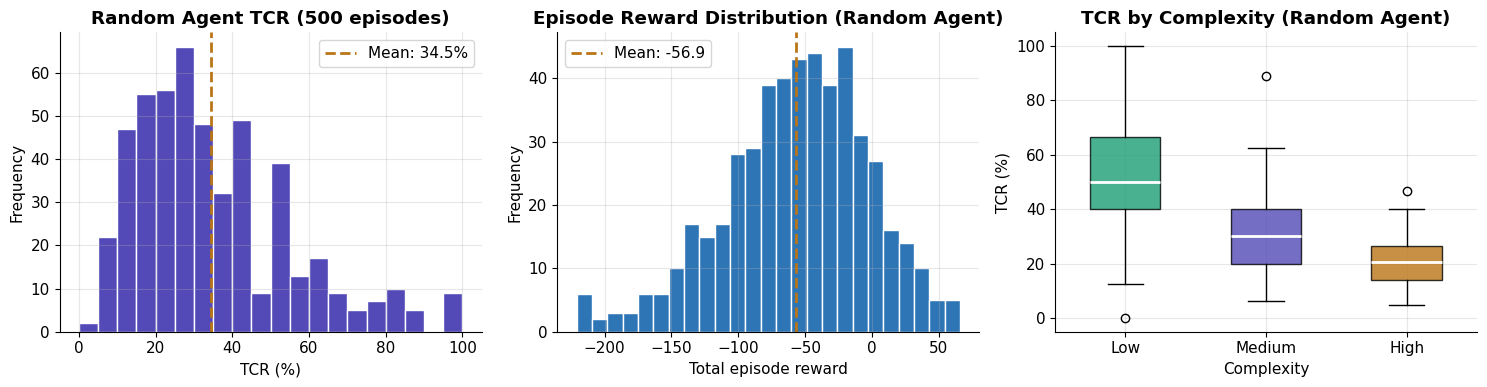

Figure saved: data/fig8_env_statistics.png


In [10]:
# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_stats['tcr']*100, bins=20, color=PALETTE[1], edgecolor='white')
axes[0].axvline(df_stats['tcr'].mean()*100, color=PALETTE[2], linestyle='--',
                linewidth=2, label=f"Mean: {df_stats['tcr'].mean()*100:.1f}%")
axes[0].set_title("Random Agent TCR (500 episodes)", fontweight="bold")
axes[0].set_xlabel("TCR (%)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].hist(df_stats['episode_reward'], bins=25, color=PALETTE[3], edgecolor='white')
axes[1].axvline(df_stats['episode_reward'].mean(), color=PALETTE[2], linestyle='--',
                linewidth=2, label=f"Mean: {df_stats['episode_reward'].mean():.1f}")
axes[1].set_title("Episode Reward Distribution (Random Agent)", fontweight="bold")
axes[1].set_xlabel("Total episode reward")
axes[1].set_ylabel("Frequency")
axes[1].legend()

for i, c in enumerate(['low', 'medium', 'high']):
    subset = df_stats[df_stats['complexity'] == c]['tcr'] * 100
    axes[2].boxplot(subset, positions=[i], widths=0.5,
                    patch_artist=True,
                    boxprops=dict(facecolor=PALETTE[i], alpha=0.8),
                    medianprops=dict(color='white', linewidth=2))
axes[2].set_xticks([0, 1, 2])
axes[2].set_xticklabels(['Low', 'Medium', 'High'])
axes[2].set_title("TCR by Complexity (Random Agent)", fontweight="bold")
axes[2].set_xlabel("Complexity")
axes[2].set_ylabel("TCR (%)")

plt.tight_layout()
plt.savefig("data/fig8_env_statistics.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: data/fig8_env_statistics.png")


## 10. DQN Compatibility Check

Final verification that the environment interface is fully compatible
with the DQN training notebook.


In [11]:
print("DQN Compatibility Check")
print("=" * 55)

env_check = TaskSchedulerEnv(train_scenarios)
state     = env_check.reset()

checks = {
    "reset() returns np.array"         : isinstance(state, np.ndarray),
    "State shape is (140,)"            : state.shape == (STATE_SIZE,),
    "State dtype is float32"           : state.dtype == np.float32,
    "observation_space_shape correct"  : env_check.observation_space_shape == (STATE_SIZE,),
    "action_space_n correct"           : env_check.action_space_n == MAX_TASKS,
    "step() returns 4 values"          : len(env_check.step(0)) == 4,
    "action_mask() returns bool array" : env_check.action_mask().dtype == bool,
    "get_metrics() returns dict"       : isinstance(env_check.get_metrics(), dict),
}

all_passed = True
for check, result in checks.items():
    status = "PASSED" if result else "FAILED"
    if not result:
        all_passed = False
    print(f"  {status}  {check}")

print()
print("Current environment state:")
env_check.reset()
env_check.render()

print()
if all_passed:
    print("All compatibility checks PASSED.")
    print("Environment is ready for DQN training.")
else:
    print("Some checks FAILED. Fix before training.")

print()
print("=" * 55)
print("  ENVIRONMENT SUMMARY")
print("=" * 55)
print(f"  State size        : {STATE_SIZE} ({MAX_TASKS} tasks x {N_FEATURES} features)")
print(f"  Action space      : {MAX_TASKS} discrete actions")
print(f"  Discount factor   : {GAMMA}")
print(f"  Training scenarios: {len(train_scenarios)}")
print(f"  Random agent TCR  : ~{df_stats['tcr'].mean()*100:.1f}% (lower bound)")
print(f"  Baseline TCR      : ~38.5% (FIFO / Priority Queue)")
print(f"  DQN target TCR    : > 75%")
print()
print("  Next step → 05_DQN_Training.ipynb")
print("=" * 55)


DQN Compatibility Check
  PASSED  reset() returns np.array
  PASSED  State shape is (140,)
  PASSED  State dtype is float32
  PASSED  observation_space_shape correct
  PASSED  action_space_n correct
  PASSED  step() returns 4 values
  PASSED  action_mask() returns bool array
  PASSED  get_metrics() returns dict

Current environment state:
  Time          : 0/600 min
  Queue size    : 17 tasks remaining
  Completed     : 0
  Missed        : 0
  Episode reward: 0.0

All compatibility checks PASSED.
Environment is ready for DQN training.

  ENVIRONMENT SUMMARY
  State size        : 140 (20 tasks x 7 features)
  Action space      : 20 discrete actions
  Discount factor   : 0.95
  Training scenarios: 800
  Random agent TCR  : ~34.5% (lower bound)
  Baseline TCR      : ~38.5% (FIFO / Priority Queue)
  DQN target TCR    : > 75%

  Next step → 05_DQN_Training.ipynb
